In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/data.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [3]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [4]:
df["TotalCharges"] = (
    df["TotalCharges"]
    .fillna(
        df["TotalCharges"].median()
    )
)

In [5]:
df["CustomerValue"] = (
    df["MonthlyCharges"]
    *
    df["tenure"]
)

In [6]:
df[
    [
        "MonthlyCharges",
        "tenure",
        "CustomerValue"
    ]
].head()

,MonthlyCharges,tenure,CustomerValue
0,29.85,1,29.85
1,56.95,34,1936.30
2,53.85,2,107.70
3,42.30,45,1903.50
4,70.70,2,141.40


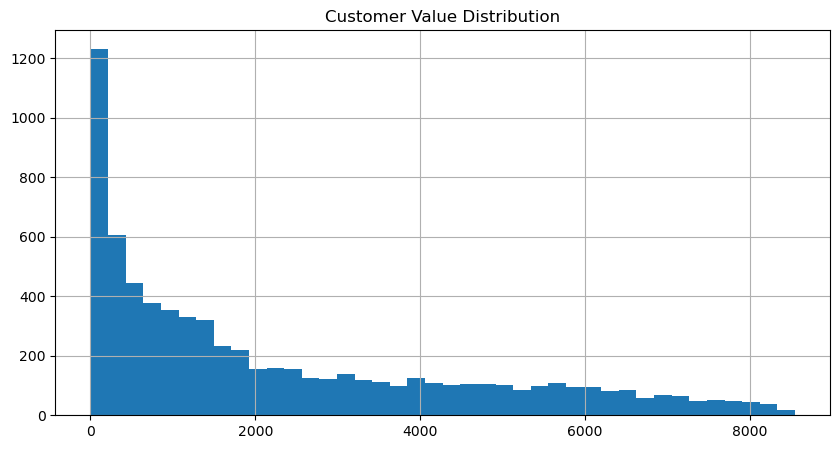

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

df["CustomerValue"].hist(
    bins=40
)

plt.title(
    "Customer Value Distribution"
)

plt.show()

In [8]:
threshold = (
    df["CustomerValue"]
    .median()
)

df["HighValueCustomer"] = (
    df["CustomerValue"]
    >
    threshold
).astype(int)

In [9]:
df["HighValueCustomer"] \
    .value_counts()

HighValueCustomer
0    3522
1    3521
Name: count, dtype: int64

In [10]:
df.to_csv(
    "../data/customer_value_data.csv",
    index=False
)

print("Saved Successfully")

Saved Successfully
